### Looking at Helium curvature on my device ###

In [145]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
%config InlineBackend.figure_format='retina'

In [3]:
from zeroheliumkit import Structure, Rectangle, Square, Ring, Circle, GeomCollection
from zeroheliumkit.src.settings import GRAY, BLUE, YELLOW2, BLACK
from zeroheliumkit.src.plotting import ColorHandler
from zeroheliumkit.src.importing import *

In [4]:
save_dir = "dump"

### Creating geometry

SommerTanner.gds // Layers in cell 'TOP': {np.int64(0), np.int64(1), np.int64(2), np.int64(3)}


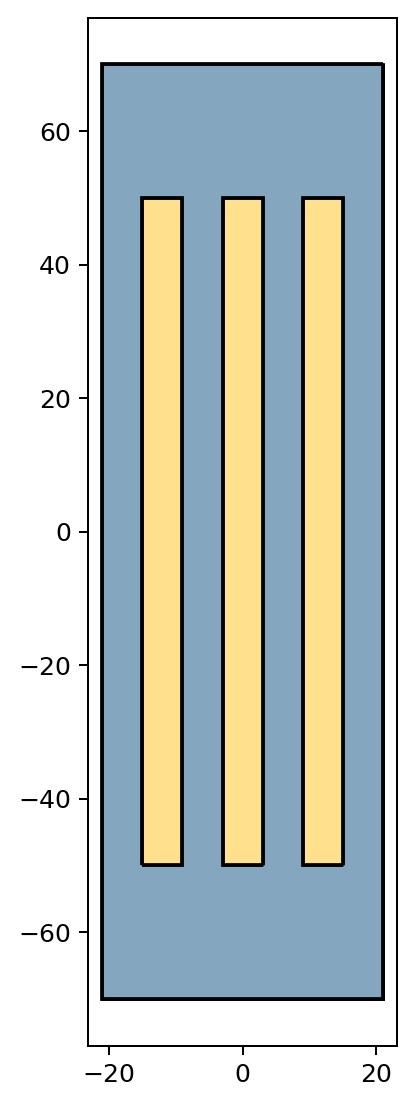

In [21]:
# Read File
file = Reader_GDS('SommerTanner.gds')
file.import2zhk("TOP")
device = GeomCollection(file.geometries)
# Rename Layers
device.rename_layer('L2','bottom')
device.rename_layer('L0','top')
device.rename_layer('L3','wafer')
device.rename_layer('L1','helium')
device.cut_polygon("top", device.helium)
device.layers

#Show Device
plot_config = {'wafer':BLACK,'bottom':YELLOW2,'top':(BLUE,0.8)}
device.quickplot(plot_config)
plt.show()


<Axes: >

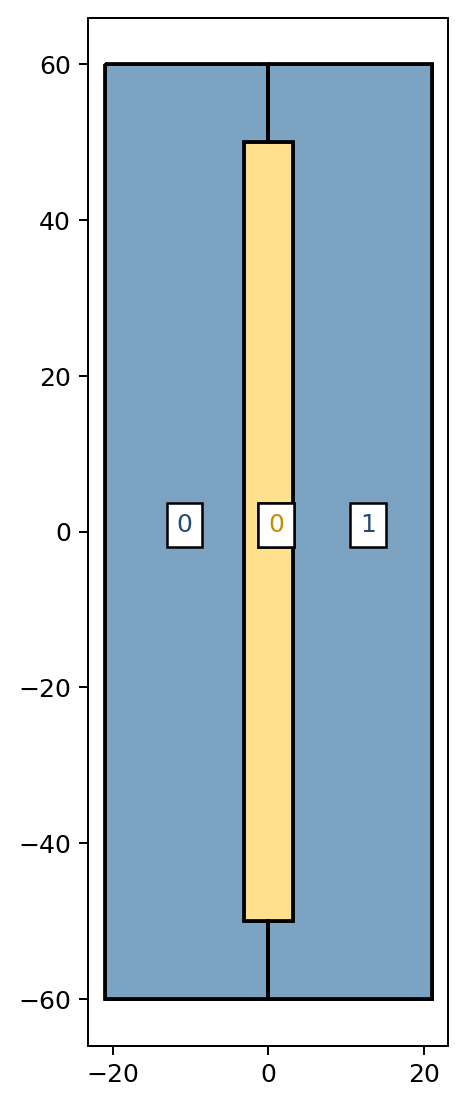

In [218]:
device = Structure()
device.add_layer("wafer", Rectangle(42,120))

device.add_layer("top", Rectangle(42,120))
device.cut_polygon("top", Rectangle(6.3, 100))

device.add_layer("bottom", Rectangle(42,120))

device.add_layer("etch", Rectangle(42,120))
device.cut_polygon("etch", device.top)


device.remove_holes_from_polygons("bottom")
device.remove_holes_from_polygons("top")

device.colors = ColorHandler({
    "wafer": GRAY,
    "bottom": YELLOW2,
    "top": (BLUE, 0.85)
})
device.quickplot(show_idx=True)

## Viewing Electrodes ##

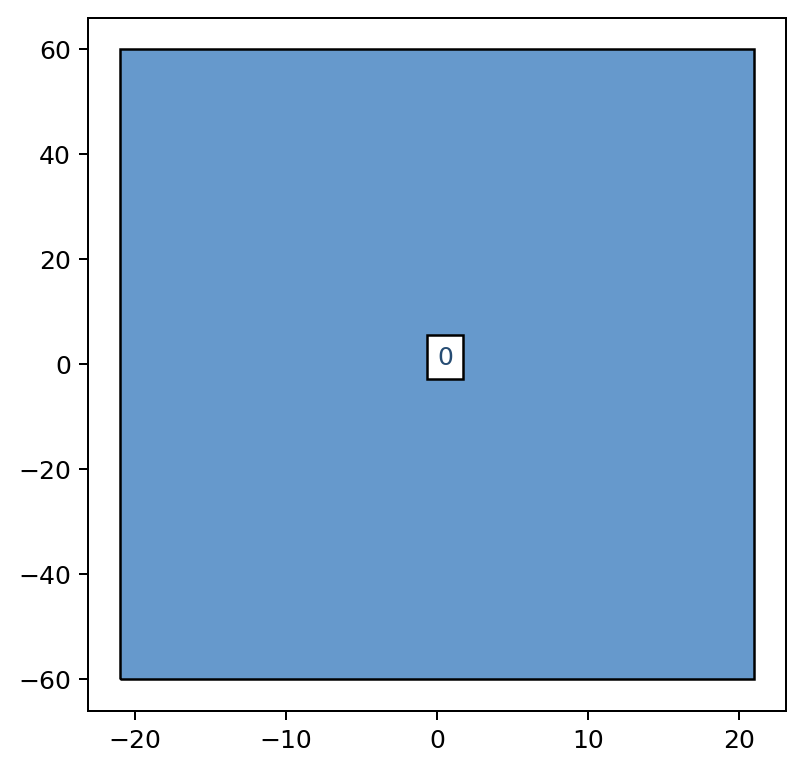

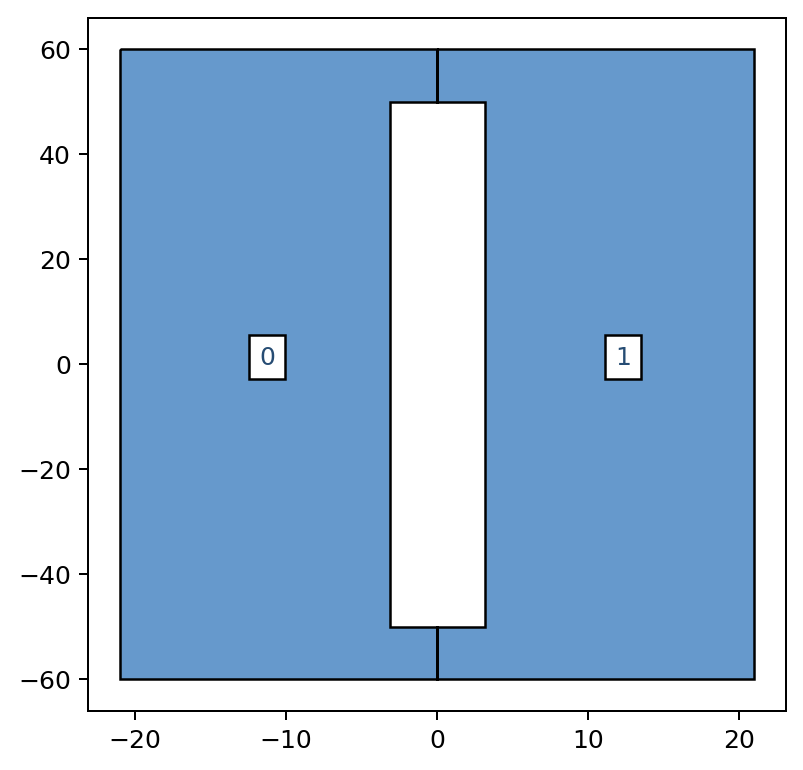

In [219]:
for layer in ["bottom","top"]:
    fig = plt.figure(1, figsize=(5,5), dpi=90)
    ax = fig.add_subplot(111)
    device.plot(ax=ax, layer=[layer],color=[BLUE],show_idx=True)
    plt.show()

### **Creating Mesh**

In [220]:
from zeroheliumkit.fem import GMSHmaker, ExtrudeSettings, MeshSettings, PECSettings, BoxFieldMeshSettings


In [221]:
# extrude parameters
d_wafer     = 10
d_metal1    = 0.025
d_metal2    = 0.025
d_diel      = 0.705
d_vac       = 25
d_He        = d_diel + d_metal2

In [222]:
Volumes = {
    'wafer':        ExtrudeSettings(device.wafer     , -d_wafer, d_wafer, 'DIELECTRIC'),
    'bottom':       ExtrudeSettings(device.bottom    , 0, d_metal1, 'METAL'),
    'dielectric':   ExtrudeSettings(device.top       , d_metal1, d_diel, 'DIELECTRIC'),
    'top':          ExtrudeSettings(device.top       , d_metal1+d_diel, d_metal2, 'METAL'),
    'helium':       ExtrudeSettings(device.wafer     , 0, d_He, 'HELIUM', ('dielectric','top')),
    'vacuum':       ExtrudeSettings(device.wafer     , d_metal1+d_He, d_vac, 'VACUUM', ('dielectric', 'top'))
}

PECs = {
    'Reservoir':    PECSettings(device.bottom ,   [0],   volume=Volumes['bottom']),
    'Top':          PECSettings(device.top ,      [0,1],   volume=Volumes['top']),
}

scale = 4
mediumregion_box = [-20, 20, -60, 60, -6, 6]
fineregion_box = [-18, 18, -50, 50, -4.5, 4.5]

mesh = MeshSettings(
    dim = 3,
    fields = {
        "Box": [BoxFieldMeshSettings(Thickness=4, VIn=scale * 0.4, VOut=scale * 1, box=mediumregion_box),
                BoxFieldMeshSettings(Thickness=2, VIn=scale * 0.2, VOut=scale * 1, box=fineregion_box)]
    }
)

In [223]:
meshMKR = GMSHmaker(
    extrude = Volumes,
    surfaces = None,
    pecs = PECs,
    mesh = mesh,
    save = {"dir": save_dir, "filename": "dot"},
    # open_gmsh = True,
    debug_mode = False
)

on 0: mesh is constructed                                                       
on 0: mesh saved                                                                
Gmsh generation  |███| 1/1 [100%] in 12.4s (0.08/s)                             


Below is an example of created geometry and a mesh using GMSH.

<img src="../_static/fig1.png" width="800"/>

In [224]:
meshMKR.print_physical()

Volume        ID
----------  ----
HELIUM         1
METAL          2
VACUUM         3
DIELECTRIC     4

 #-----------------------------------

Surface      ID
---------  ----
Reservoir     5
Top           6


### **Helium Surface Displacement calculations**

<Axes: >

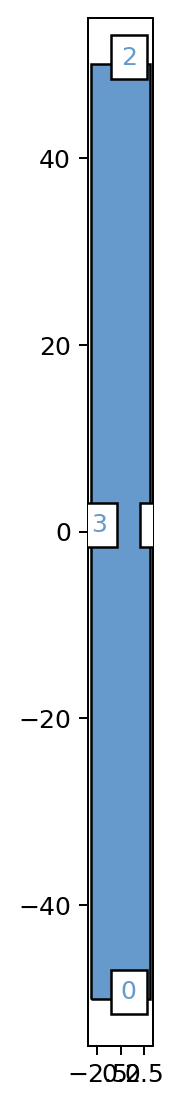

In [225]:
s = Structure()
s.add_layer('etch', device.etch)
s.quickplot(show_line_idx=True)

# We want to make boundary with line id 1 and 11 to be open boundary (Neumann boundary),
# at all other boundaries displacement is set to 0 (Dirichlet boundary)

In [226]:
from zeroheliumkit.fem.heliumsurface import GMSHmaker2D, HeliumSurfaceFreeFEM

In [227]:
gmshmkr = GMSHmaker2D(layout = s,
                      electode_config = {"type": "polygon",
                                         "bound": {"layer": ("etch", (0,)), "exclude": [-50,100], "value": 0}},
                      mesh_config = [{"Thickness": 5, "VIn": 0.9, "VOut": 0.9, "box": [-21, 21, -55, 55]}],
                      filename = "heliumsurface",
                      savedir = save_dir)
gmshmkr.disable_consoleOutput()
gmshmkr.create_mesh()
# gmshmkr.open_gmsh()
gmshmkr.finalize()

Gmsh generation  |███| 1/1 [100%] in 0.1s (9.64/s)                              


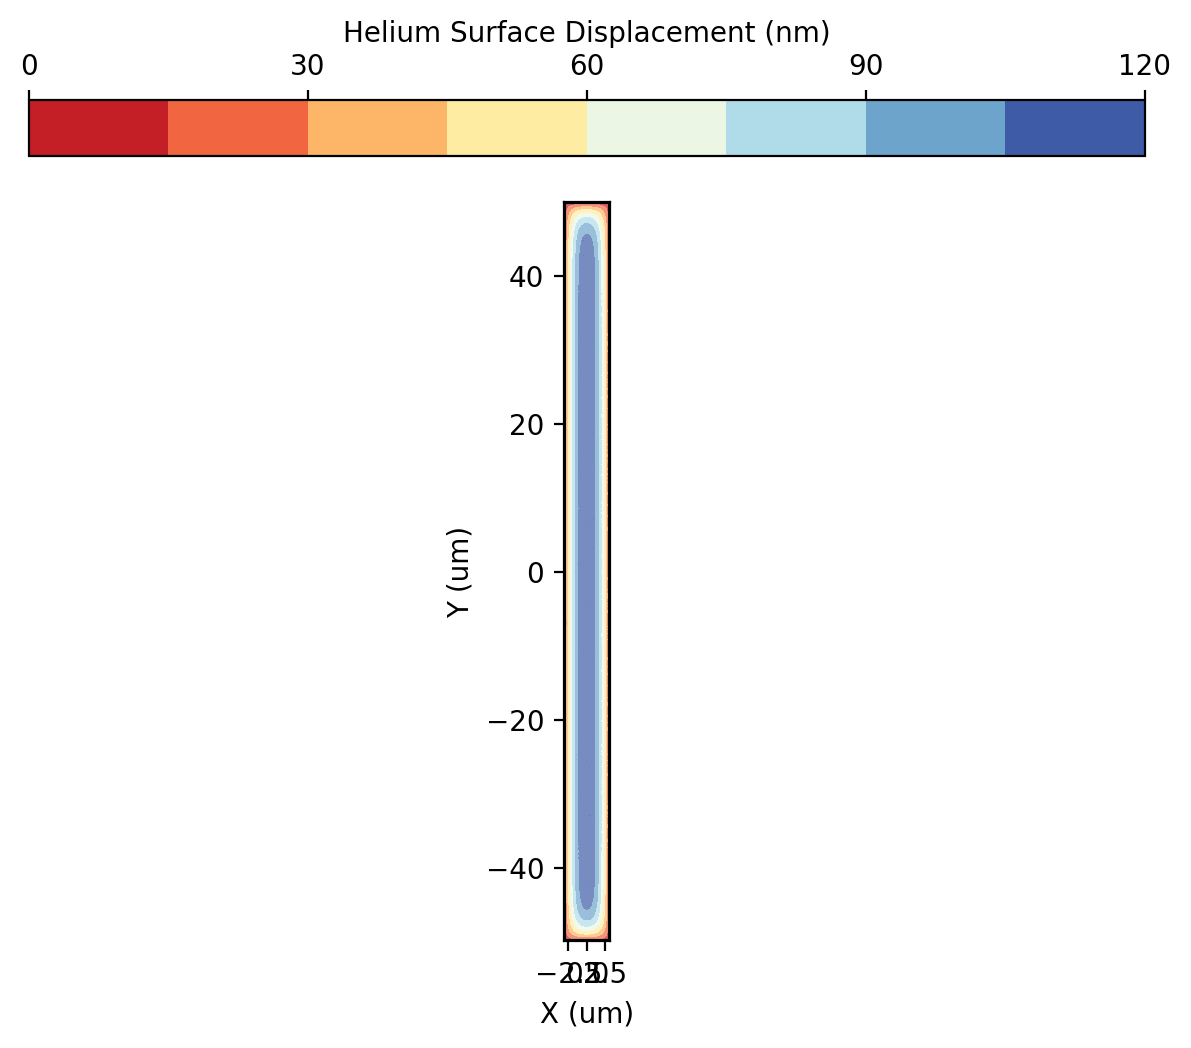

In [228]:
hsfreefem = HeliumSurfaceFreeFEM(fem_config=gmshmkr.export_physical())
res = hsfreefem.run_pyfreefem()

# plotting results of helium surface displacement for a bulk helium distance of 10 mm from the gnd surface
# note: the geometry units are in meters, so the bulk helium distance is set to 0.01m (10 mm)
hsfreefem.plot_results(res, bulk_helium_distance=0.006)


The displacement is 118.96388490030996 nm and the dmin value is 611.03611509969 nm


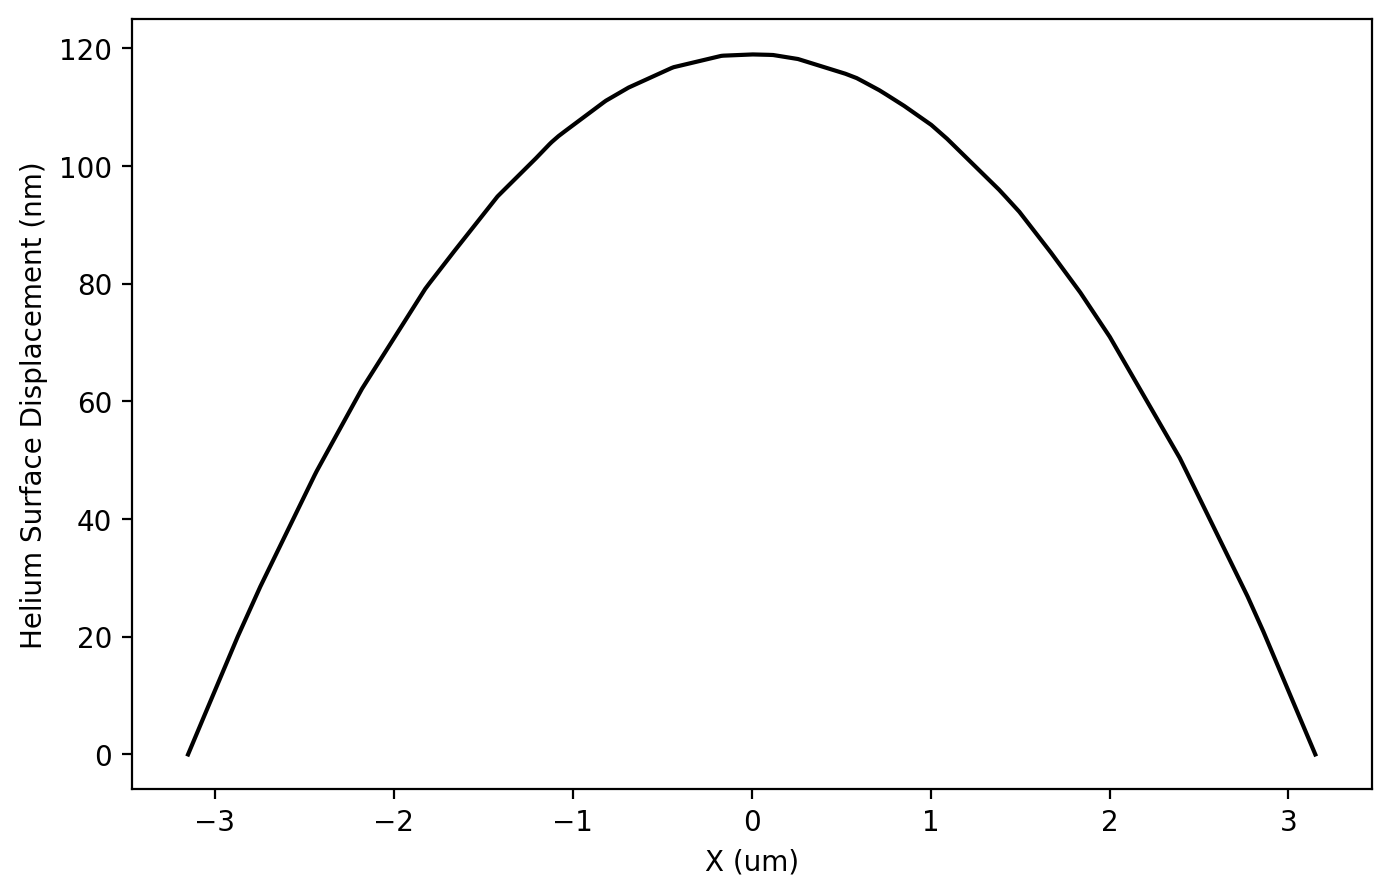

In [231]:
hsfreefem.plot_1D(res, bulk_helium_distance=0.006, cut_axis='x', cut_value=0, xlist=np.linspace(-3.15, 3.15, 500))
dmin = hsfreefem.get_displacement(res, bulk_helium_distance=0.006, location=(0,0))*1e3
print('The displacement is', dmin,'nm and the dmin value is',730-dmin,'nm')

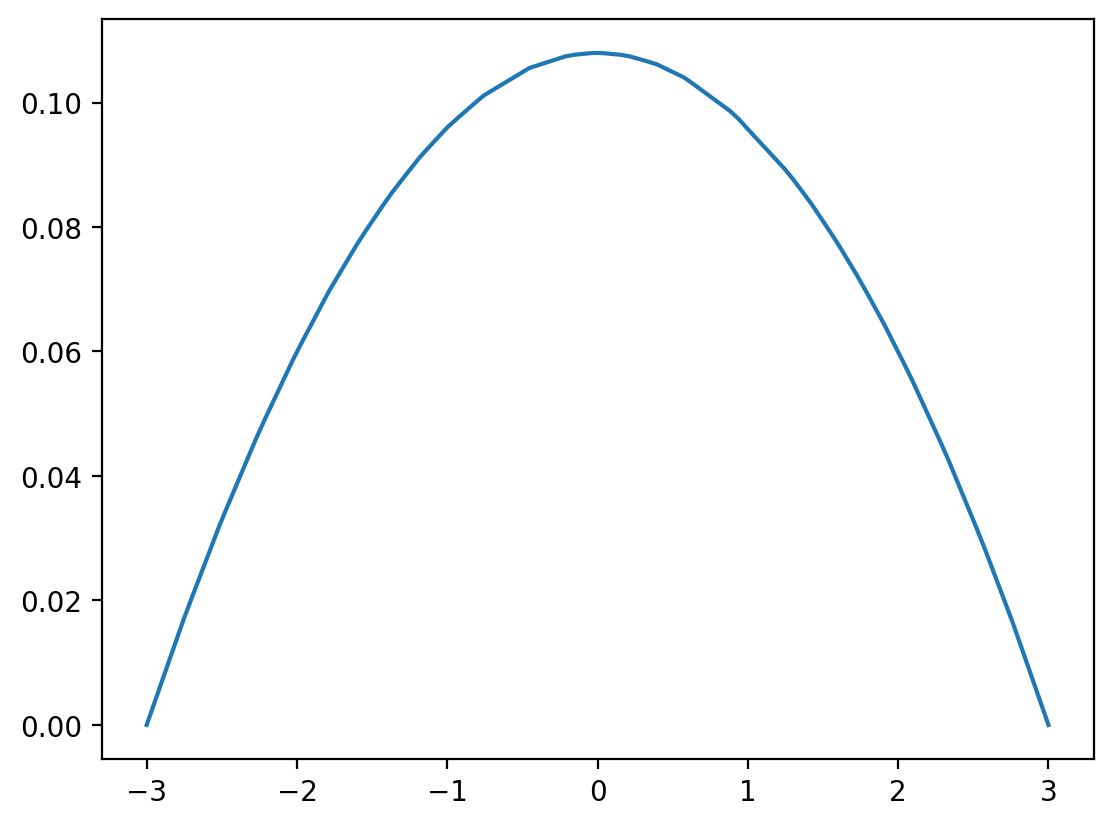

In [189]:
y_list = []
xlist = np.linspace(-3,3,100)
for n in xlist:
    y = hsfreefem.get_displacement(res, bulk_helium_distance=0.006, location=(n,0))
    y_list.append(y)
plt.plot(xlist,y_list)

In [142]:
curvature_config = hsfreefem.get_code_config(bulk_helium_distances=[0, 0.001, 0.01, 0.02], surface_helium_level=d_He)
curvature_config

{'script': 'load "gmsh"\nmesh heliumsurfTh = gmshload("dump\\\\geo\\\\heliumsurface.msh");\ncout << "Area: " << int2d(heliumsurfTh)(1.0) << endl;\n\nfespace heliumsurfVh(heliumsurfTh,P2);\nheliumsurfVh<real> disp,vdisp;\nproblem HeliumSurfaceCalculate(disp,vdisp,solver=CG) =\n    int2d(heliumsurfTh)( (dx(disp)*dx(vdisp) + dy(disp)*dy(vdisp)) )\n    - int2d(heliumsurfTh)( 1*vdisp )\n    + on (2,disp=0);\n\nHeliumSurfaceCalculate;\nheliumsurfTh = adaptmesh( heliumsurfTh, disp, hmax = .5, hmin = 0.02, iso = 1, nbvx = 10000 );\nHeliumSurfaceCalculate;\ncout << "Helium Surface Calculations are finished" << endl;\n',
 'displacement': 'disp',
 'bulk_helium_distances': [0, 0.001, 0.01, 0.02],
 'surface_helium_level': 0.73}

### **Creating FreeFem configuration**

In [19]:
from zeroheliumkit.fem.freefemer import FFconfigurator, ExtractConfig, FreeFEM

In [20]:
He_level = d_He

var_eps = {
        'DIELECTRIC': 11.0,
        'METAL': 1.0,
        'HELIUM': 1.057,
        'VACUUM': 1.0,
}

ffc = FFconfigurator(config_file="dump/dot.yaml",
                     dielectric_constants=var_eps,
                     ff_polynomial=2,
                     extract_opt=[ExtractConfig("result1", 'phi', 'xy', (-10,10,201), (-10,10,201), d_He),
                                  ExtractConfig("result2", 'phi', 'xy', (-10,10,201), (-10,10,201), curvature_config),
                                  ExtractConfig("result3", 'Ez', 'yz', (-10,10,101), (-2,2,101), 0.0)
                                  ],
                     msh_refinements=None
                     )

In [21]:
pyff = FreeFEM(config_file="dump/dot.yaml")

In [22]:
await pyff.run(cores=4, print_log=False, remove=True)  # old code had remove_txt_blah so change to remove

HTML(value='<b>⏳ Running:</b> dump\\\\edp\\\\ff_mid.edp', layout=Layout(margin='4px 0'))

HTML(value='<b>⏳ Running:</b> dump\\\\edp\\\\ff_out.edp', layout=Layout(margin='4px 0'))

HTML(value='<b>⏳ Running:</b> dump\\\\edp\\\\ff_top.edp', layout=Layout(margin='4px 0'))

### **Parsing FEM results**

In [23]:
from zeroheliumkit.fem.fieldreader import FreeFemResultParser, FieldAnalyzer
from zeroheliumkit.src.settings import BLACK, WHITE

In [24]:
ffparser = FreeFemResultParser("dump/metadata.yaml")

                result1        result2                 result3
--------------  -------------  ----------------------  -------------
Quantity        phi            phi                     Ez
Plane           xy             xy                      yz
X Min           -10            -10                     -10
X Max           10             10                      10
X Num           201            201                     101
Y Min           -10            -10                     -2
Y Max           10             10                      2
Y Num           201            201                     101
Slices          1              4                       1
Slice Values    [1.6]          [0, 0.001, 0.01, 0.02]  [0.0]
Curved Surface  False          True                    False
Schema          (1, 201, 201)  (4, 201, 201)           (1, 101, 101)
Control Electrodes: ['mid', 'out', 'top']


In [25]:
ffparser.get_capacitance_matrix()

[[-321.827, 264.586, 67.7934],
 [258.553, -1858.05, 1726.25],
 [63.2758, 1593.46, -1794.04]]

In [15]:
fa = FieldAnalyzer(("dot", ffparser.load_data("dump/results", "result1")),
                   ("curved", ffparser.load_data("dump/results", "result2")))

NameError: name 'FieldAnalyzer' is not defined

In [14]:
fa.dot

NameError: name 'fa' is not defined

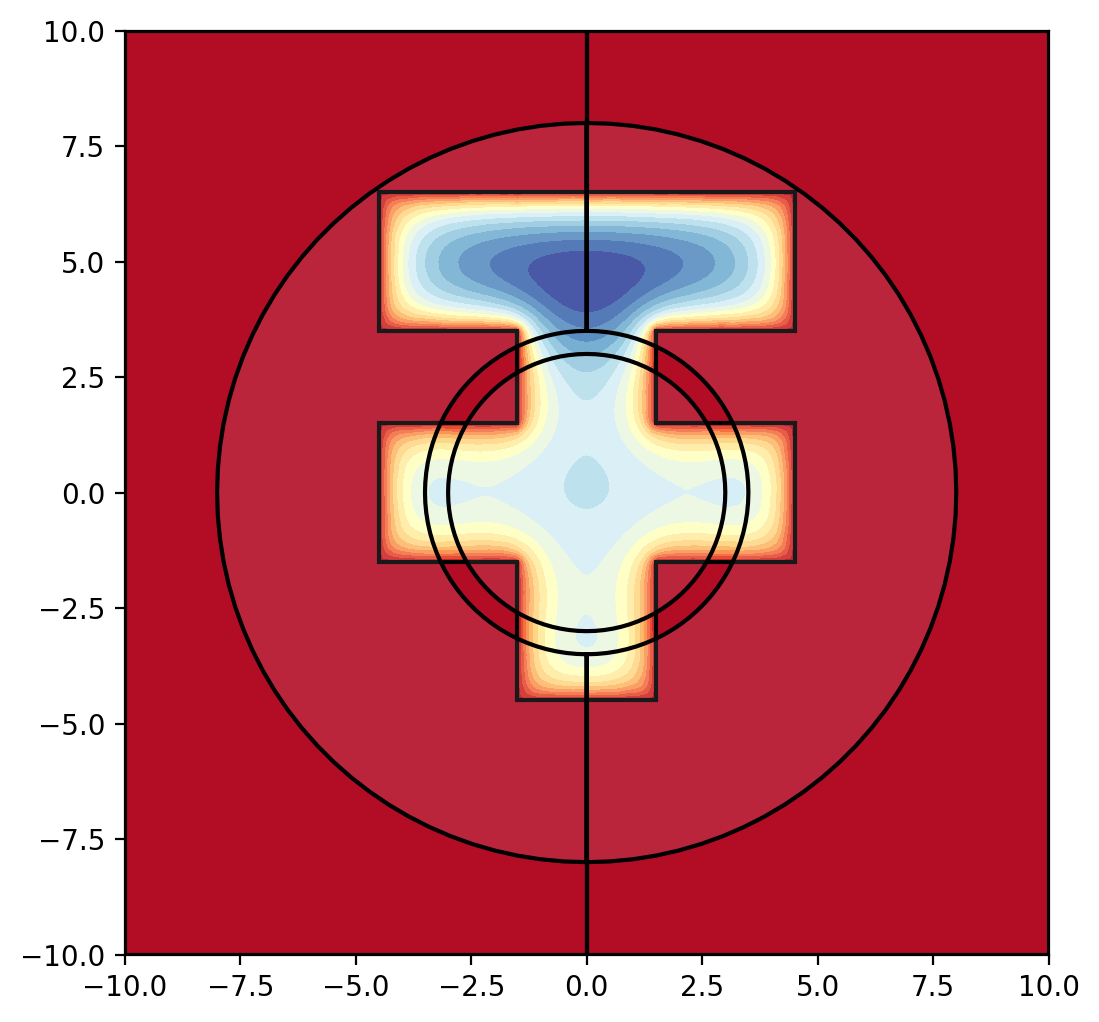

In [28]:
voltages = {
    "mid": 1,
    "out": 2,
    "top": -0.1
}

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111)

fa.plot_potential_2D(fa.dot, voltages, zlevel_key=1.6, ax=ax, zero_line=False, cmap='RdYlBu')
device.plot(ax=ax, layer=["gnd"], color=[BLACK], alpha=0)
device.plot(ax=ax, layer=["bottom"], color=[WHITE], alpha=0.1)

ax.set_aspect("equal")

plt.show()

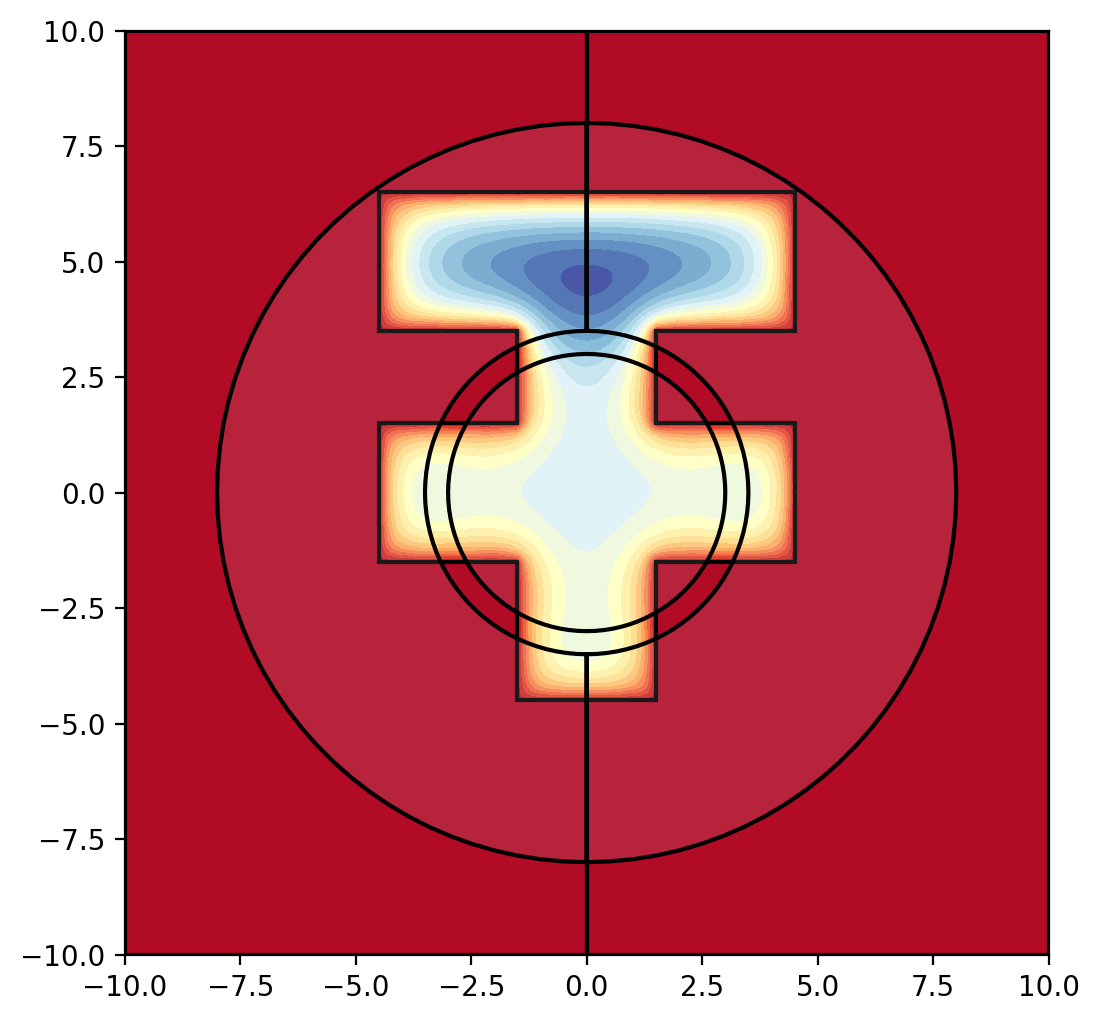

In [29]:
voltages = {
    "mid": 1,
    "out": 2,
    "top": -0.1
}

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111)

fa.plot_potential_2D(fa.curved, voltages, zlevel_key=0.02, ax=ax, zero_line=False, cmap='RdYlBu')
device.plot(ax=ax, layer=["gnd"], color=[BLACK], alpha=0)
device.plot(ax=ax, layer=["bottom"], color=[WHITE], alpha=0.1)

ax.set_aspect("equal")

plt.show()